# Case Studies in Data Science — Individual Task 1, Part 1.3
Two datasets, two ML algorithms (Decision Tree, Neural Network / MLP).

**Dataset A** (patient-level): UCI *"Diabetes 130-US hospitals for years 1999-2008"*
Source: https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008
Target: hospital readmission within 30 days (binary)

**Dataset B** (facility-level): CMS Hospital-Acquired Condition (HAC) infection data, 2023
Source: https://github.com/klocey/hospitals-data-archive
Target: elevated healthcare-associated infection risk (mean SIR > 1.0, binary)

Author: Talha Shaik (S4150701) — RMIT University


## 1. Setup

Run the next cell first. It installs/imports everything needed — scikit-learn, pandas and
matplotlib are already preinstalled on Google Colab, so this should complete instantly there.

In [1]:
# Colab already ships with these, this is just a safety net if running elsewhere
%pip install -q scikit-learn pandas matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, classification_report)
import matplotlib.pyplot as plt

RANDOM_STATE = 42
RESULTS = {}

OUT = Path(".")
DATA = OUT / "data"
FIG = OUT / "figures"
FIG.mkdir(exist_ok=True, parents=True)
DATA.mkdir(exist_ok=True, parents=True)

## 2. Load the data

This notebook needs two CSV files:
- `data/diabetic_data.csv` (UCI diabetes readmission dataset)
- `data/hac_infection_2023.csv` (CMS hospital infection dataset)

The cell below checks whether they're already present (e.g. if you cloned the GitHub repo
into Colab). If not, and you're running on **Google Colab**, it will pop up a file-upload
widget — just select both CSVs from your computer when prompted.

In [3]:
diabetic_path = DATA / "diabetic_data.csv"
hac_path = DATA / "hac_infection_2023.csv"

if not diabetic_path.exists() or not hac_path.exists():
    try:
        from google.colab import files
        print("Data files not found locally — please upload them now.")
        print("Select diabetic_data.csv and hac_infection_2023.csv (you can select both at once).")
        uploaded = files.upload()
        for fname, content in uploaded.items():
            target = DATA / fname
            with open(target, "wb") as f:
                f.write(content)
            print("Saved:", target)
    except ImportError:
        raise FileNotFoundError(
            "data/diabetic_data.csv and data/hac_infection_2023.csv not found. "
            "Place them in a 'data' folder next to this notebook, or run this "
            "notebook in Google Colab to be prompted for an upload."
        )

assert diabetic_path.exists(), "diabetic_data.csv still missing after upload step"
assert hac_path.exists(), "hac_infection_2023.csv still missing after upload step"
print("Data files ready.")

Data files ready.


## 3. Helper functions

In [4]:
def oversample_minority(X_train, y_train, random_state=RANDOM_STATE):
    """Random oversampling of the minority class in the training set only.
    Used for the neural network, which (unlike the Decision Tree) has no
    built-in class_weight support in scikit-learn."""
    train = X_train.copy()
    train["__y__"] = y_train.values
    counts = train["__y__"].value_counts()
    majority_n = counts.max()
    parts = [train[train["__y__"] == cls].sample(
        majority_n, replace=True, random_state=random_state)
        for cls in counts.index]
    balanced = pd.concat(parts).sample(frac=1, random_state=random_state)
    return balanced.drop(columns="__y__"), balanced["__y__"]


def make_preprocessor(num_cols, cat_cols):
    """Fresh ColumnTransformer instance (never share one across pipelines -
    each Pipeline.fit() mutates it in place, which would otherwise corrupt
    feature names/importances read back from an earlier-fitted pipeline)."""
    return ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])


def evaluate(name, dataset_key, y_test, y_pred, y_proba):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    cm = confusion_matrix(y_test, y_pred).tolist()
    print(f"\n--- {dataset_key} | {name} ---")
    auc_str = f"{auc:.3f}" if auc is not None else "n/a"
    print(f"Accuracy={acc:.3f} Precision={prec:.3f} Recall={rec:.3f} F1={f1:.3f} AUC={auc_str}")
    print(confusion_matrix(y_test, y_pred))
    RESULTS.setdefault(dataset_key, {})[name] = dict(
        accuracy=acc, precision=prec, recall=rec, f1=f1, auc=auc, confusion_matrix=cm
    )
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=auc, cm=cm)


def plot_confusion(cm, labels, title, path):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm, cmap="Blues")
    for i in range(len(cm)):
        for j in range(len(cm[0])):
            ax.text(j, i, cm[i][j], ha="center", va="center",
                     color="white" if cm[i][j] > np.max(cm) / 2 else "black")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()


def plot_roc(curves, title, path):
    fig, ax = plt.subplots(figsize=(5, 4))
    for label, (fpr, tpr, auc) in curves.items():
        ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.2f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(title); ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()


def plot_feature_importance(importances, feature_names, title, path, top_n=12):
    idx = np.argsort(importances)[-top_n:]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.barh(range(len(idx)), importances[idx], color="#2b6cb0")
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([feature_names[i] for i in idx])
    ax.set_xlabel("Decision Tree feature importance")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()

## 4. Dataset A — Diabetes 130-US hospitals (30-day readmission)

Patient-level data. Target: was the patient readmitted within 30 days?

In [5]:
print("=" * 70)
print("DATASET A: Diabetes 130-US hospitals - 30-day readmission")
print("=" * 70)

dfA = pd.read_csv(diabetic_path)
print("Raw shape:", dfA.shape)

# Drop encounters where patient died or was discharged to hospice (cannot be readmitted)
expired_hospice = [11, 13, 14, 19, 20, 21]
dfA = dfA[~dfA["discharge_disposition_id"].isin(expired_hospice)]

# Keep first encounter per patient to avoid leakage from repeated patients
dfA = dfA.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first")

# Target
dfA["readmit_30d"] = (dfA["readmitted"] == "<30").astype(int)

# Age bracket -> midpoint
age_map = {f"[{i}-{i+10})": i + 5 for i in range(0, 100, 10)}
dfA["age_mid"] = dfA["age"].map(age_map)

# ICD-9 diag_1 -> broad clinical category (standard grouping used in Strack et al. 2014)
def icd9_group(code):
    if pd.isna(code) or code == "?":
        return "Missing"
    if str(code).startswith(("V", "E")):
        return "Other"
    try:
        c = float(code)
    except ValueError:
        return "Other"
    if 390 <= c <= 459 or c == 785:
        return "Circulatory"
    if 460 <= c <= 519 or c == 786:
        return "Respiratory"
    if 520 <= c <= 579 or c == 787:
        return "Digestive"
    if 250 <= c < 251:
        return "Diabetes"
    if 800 <= c <= 999:
        return "Injury"
    if 710 <= c <= 739:
        return "Musculoskeletal"
    if 580 <= c <= 629 or c == 788:
        return "Genitourinary"
    if 140 <= c <= 239:
        return "Neoplasms"
    return "Other"

dfA["diag_1_group"] = dfA["diag_1"].apply(icd9_group)

# Bucket medical_specialty into top categories
top_spec = dfA["medical_specialty"].value_counts().nlargest(8).index
dfA["specialty_grp"] = dfA["medical_specialty"].where(dfA["medical_specialty"].isin(top_spec), "Other/Missing")

num_cols = ["age_mid", "time_in_hospital", "num_lab_procedures", "num_procedures",
            "num_medications", "number_outpatient", "number_emergency",
            "number_inpatient", "number_diagnoses"]
cat_cols = ["race", "gender", "diag_1_group", "specialty_grp", "max_glu_serum",
            "A1Cresult", "insulin", "change", "diabetesMed"]

dfA_model = dfA[num_cols + cat_cols + ["readmit_30d"]].copy()
for c in cat_cols:
    dfA_model[c] = dfA_model[c].fillna("Missing").replace("?", "Missing")
dfA_model = dfA_model.dropna(subset=num_cols)

print("Modelling shape (unique patients, expired/hospice removed):", dfA_model.shape)
print("Positive rate (readmit <30d):", dfA_model["readmit_30d"].mean().round(3))

XA = dfA_model[num_cols + cat_cols]
yA = dfA_model["readmit_30d"]

XA_train, XA_test, yA_train, yA_test = train_test_split(
    XA, yA, test_size=0.2, stratify=yA, random_state=RANDOM_STATE)

DATASET A: Diabetes 130-US hospitals - 30-day readmission


Raw shape: (101766, 50)
Modelling shape (unique patients, expired/hospice removed): (69990, 19)
Positive rate (readmit <30d): 0.09


In [6]:
# Decision Tree
dtA = Pipeline([("prep", make_preprocessor(num_cols, cat_cols)), ("clf", DecisionTreeClassifier(
    max_depth=6, min_samples_leaf=50, class_weight="balanced", random_state=RANDOM_STATE))])
dtA.fit(XA_train, yA_train)
dtA_pred = dtA.predict(XA_test)
dtA_proba = dtA.predict_proba(XA_test)[:, 1]
evaluate("Decision Tree", "A_diabetes_readmission", yA_test, dtA_pred, dtA_proba)

# Neural network (MLP) - trained on a class-balanced (oversampled) training set
XA_train_bal, yA_train_bal = oversample_minority(XA_train, yA_train)
nnA = Pipeline([("prep", make_preprocessor(num_cols, cat_cols)), ("clf", MLPClassifier(
    hidden_layer_sizes=(32, 16), max_iter=300, random_state=RANDOM_STATE, early_stopping=True))])
nnA.fit(XA_train_bal, yA_train_bal)
nnA_pred = nnA.predict(XA_test)
nnA_proba = nnA.predict_proba(XA_test)[:, 1]
evaluate("Neural Network (MLP)", "A_diabetes_readmission", yA_test, nnA_pred, nnA_proba)


--- A_diabetes_readmission | Decision Tree ---
Accuracy=0.603 Precision=0.115 Recall=0.512 F1=0.188 AUC=0.585
[[7803 4938]
 [ 614  643]]



--- A_diabetes_readmission | Neural Network (MLP) ---
Accuracy=0.601 Precision=0.107 Recall=0.469 F1=0.174 AUC=0.560
[[7828 4913]
 [ 668  589]]


{'accuracy': 0.6013001857408201,
 'precision': 0.10705198109778262,
 'recall': 0.46857597454256167,
 'f1': 0.17428613700251516,
 'auc': 0.5603543943259245,
 'cm': [[7828, 4913], [668, 589]]}

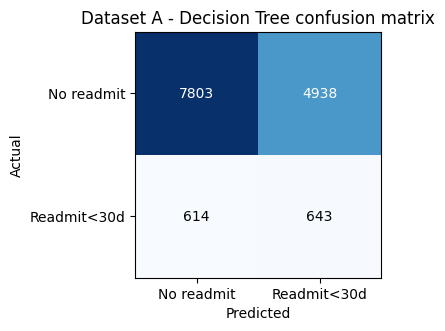

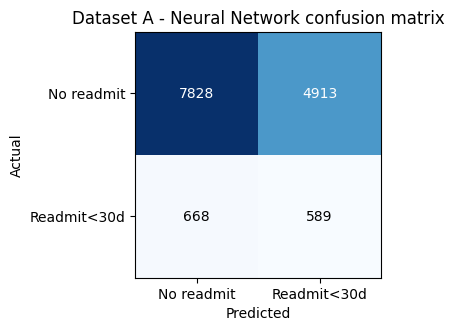

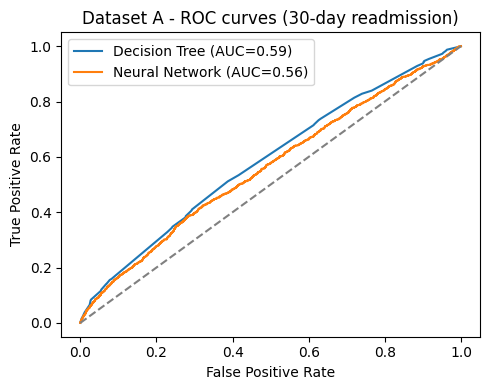

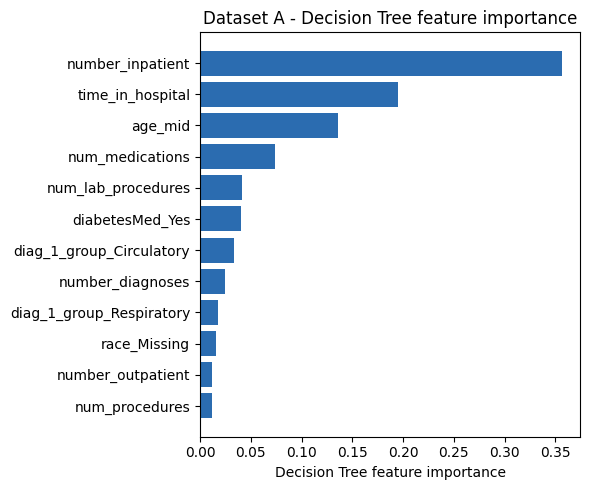

In [7]:
# Plots
cmA = confusion_matrix(yA_test, dtA_pred)
plot_confusion(cmA, ["No readmit", "Readmit<30d"], "Dataset A - Decision Tree confusion matrix",
               FIG / "A_dt_confusion.png")
cmA_nn = confusion_matrix(yA_test, nnA_pred)
plot_confusion(cmA_nn, ["No readmit", "Readmit<30d"], "Dataset A - Neural Network confusion matrix",
               FIG / "A_nn_confusion.png")

fprA_dt, tprA_dt, _ = roc_curve(yA_test, dtA_proba)
fprA_nn, tprA_nn, _ = roc_curve(yA_test, nnA_proba)
plot_roc({
    "Decision Tree": (fprA_dt, tprA_dt, roc_auc_score(yA_test, dtA_proba)),
    "Neural Network": (fprA_nn, tprA_nn, roc_auc_score(yA_test, nnA_proba)),
}, "Dataset A - ROC curves (30-day readmission)", FIG / "A_roc.png")

feat_namesA = (num_cols +
               list(dtA.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_cols)))
importA = dtA.named_steps["clf"].feature_importances_
plot_feature_importance(importA, feat_namesA, "Dataset A - Decision Tree feature importance",
                         FIG / "A_feature_importance.png")

top_features_A = [feat_namesA[i] for i in np.argsort(importA)[-8:][::-1]]
RESULTS["A_diabetes_readmission"]["n_rows"] = int(dfA_model.shape[0])
RESULTS["A_diabetes_readmission"]["positive_rate"] = float(dfA_model["readmit_30d"].mean())
RESULTS["A_diabetes_readmission"]["top_features"] = top_features_A

## 5. Dataset B — CMS Hospital-Acquired Condition infection data (2023)

Facility-level data. Target: is the hospital's mean standardised infection ratio (SIR)
above the national benchmark of 1.0?

In [8]:
print("\n" + "=" * 70)
print("DATASET B: CMS HAC infection data 2023 - elevated infection risk")
print("=" * 70)

dfB = pd.read_csv(hac_path)

sir_cols = ["CAUTI SIR", "CDI SIR", "CLABSI SIR", "MRSA SIR", "SSI SIR"]
dfB["n_available"] = dfB[sir_cols].notna().sum(axis=1)
dfB = dfB[dfB["n_available"] >= 3].copy()
dfB["mean_sir"] = dfB[sir_cols].mean(axis=1)
dfB["elevated_risk"] = (dfB["mean_sir"] > 1.0).astype(int)
dfB = dfB.dropna(subset=["Beds", "State"])

# Group states into US Census regions to reduce cardinality
region_map = {
    **{s: "Northeast" for s in ["CT","ME","MA","NH","RI","VT","NJ","NY","PA"]},
    **{s: "Midwest" for s in ["IL","IN","MI","OH","WI","IA","KS","MN","MO","NE","ND","SD"]},
    **{s: "South" for s in ["DE","FL","GA","MD","NC","SC","VA","DC","WV","AL","KY","MS","TN","AR","LA","OK","TX"]},
    **{s: "West" for s in ["AZ","CO","ID","MT","NV","NM","UT","WY","AK","CA","HI","OR","WA"]},
}
dfB["region"] = dfB["State"].map(region_map).fillna("Other/Territory")

num_colsB = ["Beds"]
cat_colsB = ["Hospital Ownership", "region"]

XB = dfB[num_colsB + cat_colsB]
yB = dfB["elevated_risk"]

print("Modelling shape (facilities with >=3 of 5 SIR measures reported):", dfB.shape)
print("Positive rate (elevated infection risk):", yB.mean().round(3))

XB_train, XB_test, yB_train, yB_test = train_test_split(
    XB, yB, test_size=0.2, stratify=yB, random_state=RANDOM_STATE)


DATASET B: CMS HAC infection data 2023 - elevated infection risk
Modelling shape (facilities with >=3 of 5 SIR measures reported): (2118, 19)
Positive rate (elevated infection risk): 0.331


In [9]:
dtB = Pipeline([("prep", make_preprocessor(num_colsB, cat_colsB)), ("clf", DecisionTreeClassifier(
    max_depth=4, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE))])
dtB.fit(XB_train, yB_train)
dtB_pred = dtB.predict(XB_test)
dtB_proba = dtB.predict_proba(XB_test)[:, 1]
evaluate("Decision Tree", "B_hospital_infection_risk", yB_test, dtB_pred, dtB_proba)

XB_train_bal, yB_train_bal = oversample_minority(XB_train, yB_train)
nnB = Pipeline([("prep", make_preprocessor(num_colsB, cat_colsB)), ("clf", MLPClassifier(
    hidden_layer_sizes=(16, 8), max_iter=500, random_state=RANDOM_STATE, early_stopping=True))])
nnB.fit(XB_train_bal, yB_train_bal)
nnB_pred = nnB.predict(XB_test)
nnB_proba = nnB.predict_proba(XB_test)[:, 1]
evaluate("Neural Network (MLP)", "B_hospital_infection_risk", yB_test, nnB_pred, nnB_proba)


--- B_hospital_infection_risk | Decision Tree ---
Accuracy=0.547 Precision=0.367 Recall=0.514 F1=0.429 AUC=0.566
[[160 124]
 [ 68  72]]

--- B_hospital_infection_risk | Neural Network (MLP) ---
Accuracy=0.351 Precision=0.333 Recall=0.964 F1=0.495 AUC=0.472
[[ 14 270]
 [  5 135]]


{'accuracy': 0.35141509433962265,
 'precision': 0.3333333333333333,
 'recall': 0.9642857142857143,
 'f1': 0.4954128440366973,
 'auc': 0.47245975855130784,
 'cm': [[14, 270], [5, 135]]}

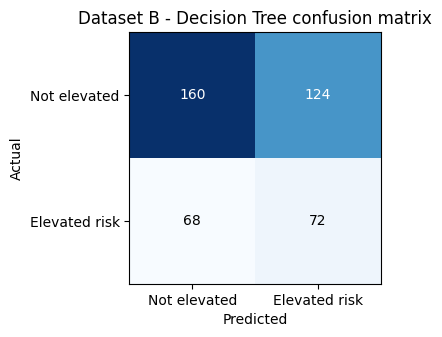

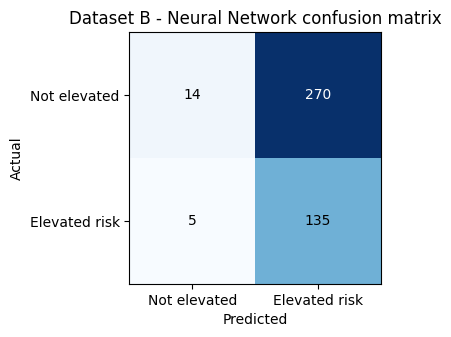

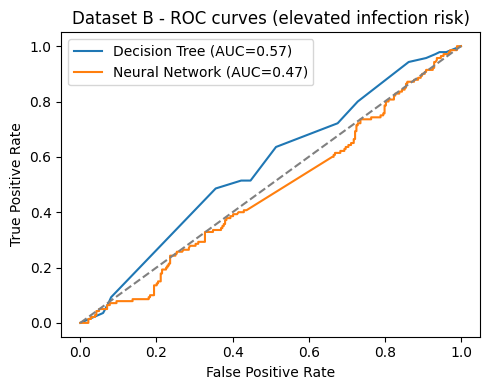

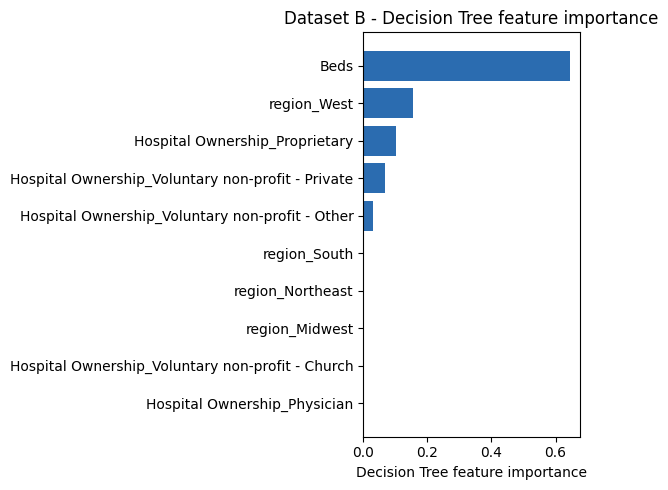

In [10]:
cmB = confusion_matrix(yB_test, dtB_pred)
plot_confusion(cmB, ["Not elevated", "Elevated risk"], "Dataset B - Decision Tree confusion matrix",
               FIG / "B_dt_confusion.png")
cmB_nn = confusion_matrix(yB_test, nnB_pred)
plot_confusion(cmB_nn, ["Not elevated", "Elevated risk"], "Dataset B - Neural Network confusion matrix",
               FIG / "B_nn_confusion.png")

fprB_dt, tprB_dt, _ = roc_curve(yB_test, dtB_proba)
fprB_nn, tprB_nn, _ = roc_curve(yB_test, nnB_proba)
plot_roc({
    "Decision Tree": (fprB_dt, tprB_dt, roc_auc_score(yB_test, dtB_proba)),
    "Neural Network": (fprB_nn, tprB_nn, roc_auc_score(yB_test, nnB_proba)),
}, "Dataset B - ROC curves (elevated infection risk)", FIG / "B_roc.png")

feat_namesB = (num_colsB +
               list(dtB.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_colsB)))
importB = dtB.named_steps["clf"].feature_importances_
plot_feature_importance(importB, feat_namesB, "Dataset B - Decision Tree feature importance",
                         FIG / "B_feature_importance.png", top_n=10)

top_features_B = [feat_namesB[i] for i in np.argsort(importB)[-8:][::-1]]
RESULTS["B_hospital_infection_risk"]["n_rows"] = int(dfB.shape[0])
RESULTS["B_hospital_infection_risk"]["positive_rate"] = float(yB.mean())
RESULTS["B_hospital_infection_risk"]["top_features"] = top_features_B

## 6. Save results

In [11]:
with open(OUT / "results.json", "w") as f:
    json.dump(RESULTS, f, indent=2)

print("Saved results.json and figures to", FIG.resolve())
print(json.dumps(RESULTS, indent=2))

Saved results.json and figures to /sessions/gracious-eloquent-wozniak/mnt/outputs/figures
{
  "A_diabetes_readmission": {
    "Decision Tree": {
      "accuracy": 0.6033719102728962,
      "precision": 0.1152123275398674,
      "recall": 0.5115354017501988,
      "f1": 0.18806668616554548,
      "auc": 0.585320088362247,
      "confusion_matrix": [
        [
          7803,
          4938
        ],
        [
          614,
          643
        ]
      ]
    },
    "Neural Network (MLP)": {
      "accuracy": 0.6013001857408201,
      "precision": 0.10705198109778262,
      "recall": 0.46857597454256167,
      "f1": 0.17428613700251516,
      "auc": 0.5603543943259245,
      "confusion_matrix": [
        [
          7828,
          4913
        ],
        [
          668,
          589
        ]
      ]
    },
    "n_rows": 69990,
    "positive_rate": 0.08979854264894985,
    "top_features": [
      "number_inpatient",
      "time_in_hospital",
      "age_mid",
      "num_medications",